In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as ss
import base64
import seaborn
from PIL import Image
from io import BytesIO
import io

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# %cd /content/drive/MyDrive/RevolveAI/apotheka/apotheka/mental_health/notebooks

In [2]:
## class/functions cell
class apotheka:
    def __init__(self, input_dict, data_dir, correlation='compute'):
        # input dictionary update
        if 'feature_names' not in input_dict.keys():
            input_dict.update({'feature_names':['id', 'case', 'Alprazolam12', 'Alprazolam24', 'als12', 'als24', 'ami12', 'ami24', 'amp12', 'amp24', 'analgesic12', 'analgesic24', 'anticonvulsant12', 'anticonvulsant24', 'antidep12', 'antidep24', 'antipsy12', 'antipsy24', 'anyattempt1', 'anyattempt12', 'anyattempt18', 'anyattempt2', 'anyattempt24', 'anyattempt3', 'anyattempt6', 'anybipol12', 'anybipol24', 'AnyEDvisits_prior1', 'AnyEDvisits_prior12', 'AnyEDvisits_prior18', 'AnyEDvisits_prior2', 'AnyEDvisits_prior24', 'AnyEDvisits_prior3', 'AnyEDvisits_prior6', 'AnyIPSub_prior12', 'AnyIPSub_prior24', 'AnyMHBed_prior12', 'AnyMHBed_prior24', 'AnyMHDisPrior12Mos', 'AnyMHDisPrior1Mos', 'AnyMHDisPrior24Mos', 'AnyMHDisPrior3Mos', 'AnyMHDisPrior6Mos', 'anyMHdx12', 'anyMHdx24', 'anyMHtx12', 'anyMHtx24', 'AnyPain12', 'AnyPain24', 'AnyResBed_prior12', 'AnyResBed_prior24', 'AnyResSub_prior12', 'AnyResSub_prior24', 'AnyUCvisits_prior1', 'AnyUCvisits_prior12', 'AnyUCvisits_prior18', 'AnyUCvisits_prior2', 'AnyUCvisits_prior24', 'AnyUCvisits_prior3', 'AnyUCvisits_prior6', 'AnyUsein10MoPrior', 'AnyUsein11MoPrior', 'AnyUsein12MoPrior', 'AnyUsein13MoPrior', 'AnyUsein14MoPrior', 'AnyUsein15MoPrior', 'AnyUsein16MoPrior', 'AnyUsein17MoPrior', 'AnyUsein18MoPrior', 'AnyUsein19MoPrior', 'AnyUsein1MoPrior', 'AnyUsein20MoPrior', 'AnyUsein21MoPrior', 'AnyUsein22MoPrior', 'AnyUsein23MoPrior', 'AnyUsein24MoPrior', 'AnyUsein2MoPrior', 'AnyUsein3MoPrior', 'AnyUsein4MoPrior', 'AnyUsein5MoPrior', 'AnyUsein6MoPrior', 'AnyUsein7MoPrior', 'AnyUsein8MoPrior', 'AnyUsein9MoPrior', 'apnea12', 'apnea24', 'ARB12', 'ARB24', 'arth12', 'arth24', 'auto12', 'auto24', 'backpain12', 'backpain24', 'bipolI12', 'bipolI24', 'bipolII12', 'bipolII24', 'blind12', 'blind24', 'ca_head12', 'ca_head24', 'ca_prost12', 'ca_prost24', 'ca12', 'ca24', 'cad12', 'cad24', 'cancer12', 'cancer24', 'cess12', 'cess24', 'chronic12', 'chronic24', 'Clonazepam12', 'Clonazepam24', 'conc12', 'conc24', 'copd12', 'copd24', 'CurrIPSub', 'CurrMHBed', 'CurrResBed', 'CurrResSub', 'cush12', 'cush24', 'cva12', 'cva24', 'cvd12', 'cvd24', 'dementia12', 'dementia24', 'depr12', 'depr24', 'dm12', 'dm24', 'dt12', 'dt24', 'dysthymia12', 'dysthymia24', 'ep12', 'ep24', 'fib12', 'fib24', 'FirstUse1Yr', 'FirstUse2Yr', 'FirstUse3Yr', 'FirstUse4Yr', 'gu12', 'gu24', 'ha12', 'ha24', 'hc12', 'hc24', 'hear12', 'hear24', 'hemi12', 'hemi24', 'highrisk', 'hiv12', 'hiv24', 'homeless12', 'homeless24', 'hyp12', 'hyp24', 'lagca12', 'lagca24', 'Lorazepam12', 'Lorazepam24', 'mig12', 'mig24', 'Mirtazepam12', 'Mirtazepam24', 'moodst12', 'moodst24', 'ms12', 'ms24', 'neuro12', 'neuro24', 'opioid12', 'opioid24', 'OthAnxDis12', 'OthAnxDis24', 'OthPsych12', 'OthPsych24', 'par12', 'par24', 'Persond12', 'Persond24', 'psy12', 'psy24', 'ptsd12', 'ptsd24', 'ra12', 'ra24', 'rd12', 'rd24', 'relax12', 'relax24', 'schizo12', 'schizo24', 'sci12', 'sci24', 'sedative_anxiolytic12', 'sedative_anxiolytic24', 'Sildenafil12', 'Sildenafil24', 'sle12', 'sle24', 'sleep12', 'sleep24', 'Statin12', 'Statin24', 'sud12', 'sud24', 'symptom12', 'symptom24', 'tbi12', 'tbi24', 'TCA12', 'TCA24', 'tension12', 'tension24', 'thy12', 'thy24', 'tobacco12', 'tobacco24', 'topical12', 'topical24', 'Trazodone12', 'Trazodone24', 'use12', 'use24', 'vet12', 'vet24', 'vision12', 'vision24', 'Zolpidem12', 'Zolpidem24', 'age', 'Attempt1', 'Attempt12', 'Attempt18', 'Attempt2', 'Attempt24', 'Attempt3', 'Attempt6', 'change_divide', 'change_Sq', 'change_subtract', 'CumDaysUsein12MoPrior', 'CumDaysUsein18MoPrior', 'CumDaysUsein1MoPrior', 'CumDaysUsein24MoPrior', 'CumDaysUsein2MoPrior', 'CumDaysUsein3MoPrior', 'CumDaysUsein6MoPrior', 'CumIPDaysUsein12MoPrior', 'CumIPDaysUsein18MoPrior', 'CumIPDaysUsein1MoPrior', 'CumIPDaysUsein24MoPrior', 'CumIPDaysUsein2MoPrior', 'CumIPDaysUsein3MoPrior', 'CumIPDaysUsein6MoPrior', 'CumIPMHDaysUsein12MoPrior', 'CumIPMHDaysUsein18MoPrior', 'CumIPMHDaysUsein1MoPrior', 'CumIPMHDaysUsein24MoPrior', 'CumIPMHDaysUsein2MoPrior', 'CumIPMHDaysUsein3MoPrior', 'CumIPMHDaysUsein6MoPrior', 'CumOPDaysUsein12MoPrior', 'CumOPDaysUsein18MoPrior', 'CumOPDaysUsein1MoPrior', 'CumOPDaysUsein24MoPrior', 'CumOPDaysUsein2MoPrior', 'CumOPDaysUsein3MoPrior', 'CumOPDaysUsein6MoPrior', 'CumOPMHDaysUsein12MoPrior', 'CumOPMHDaysUsein18MoPrior', 'CumOPMHDaysUsein1MoPrior', 'CumOPMHDaysUsein24MoPrior', 'CumOPMHDaysUsein2MoPrior', 'CumOPMHDaysUsein3MoPrior', 'CumOPMHDaysUsein6MoPrior', 'DaysLastED', 'DaysLastIPsub', 'DaysLastMHbed', 'DaysLastResbed', 'DaysLastResSub', 'DaysUsein10MoPrior', 'DaysUsein11MoPrior', 'DaysUsein12MoPrior', 'DaysUsein13MoPrior', 'DaysUsein14MoPrior', 'DaysUsein15MoPrior', 'DaysUsein16MoPrior', 'DaysUsein17MoPrior', 'DaysUsein18MoPrior', 'DaysUsein19MoPrior', 'DaysUsein1MoPrior', 'DaysUsein20MoPrior', 'DaysUsein21MoPrior', 'DaysUsein22MoPrior', 'DaysUsein23MoPrior', 'DaysUsein24MoPrior', 'DaysUsein2MoPrior', 'DaysUsein3MoPrior', 'DaysUsein4MoPrior', 'DaysUsein5MoPrior', 'DaysUsein6MoPrior', 'DaysUsein7MoPrior', 'DaysUsein8MoPrior', 'DaysUsein9MoPrior', 'dob', 'EDvisits_prior1', 'EDvisits_prior12', 'EDvisits_prior18', 'EDvisits_prior2', 'EDvisits_prior24', 'EDvisits_prior3', 'EDvisits_prior6', 'FirstUse5yr', 'IPDaysUsein10MoPrior', 'IPDaysUsein11MoPrior', 'IPDaysUsein12MoPrior', 'IPDaysUsein13MoPrior', 'IPDaysUsein14MoPrior', 'IPDaysUsein15MoPrior', 'IPDaysUsein16MoPrior', 'IPDaysUsein17MoPrior', 'IPDaysUsein18MoPrior', 'IPDaysUsein19MoPrior', 'IPDaysUsein1MoPrior', 'IPDaysUsein20MoPrior', 'IPDaysUsein21MoPrior', 'IPDaysUsein22MoPrior', 'IPDaysUsein23MoPrior', 'IPDaysUsein24MoPrior', 'IPDaysUsein2MoPrior', 'IPDaysUsein3MoPrior', 'IPDaysUsein4MoPrior', 'IPDaysUsein5MoPrior', 'IPDaysUsein6MoPrior', 'IPDaysUsein7MoPrior', 'IPDaysUsein8MoPrior', 'IPDaysUsein9MoPrior', 'IPMHDaysUsein10MoPrior', 'IPMHDaysUsein11MoPrior', 'IPMHDaysUsein12MoPrior', 'IPMHDaysUsein13MoPrior', 'IPMHDaysUsein14MoPrior', 'IPMHDaysUsein15MoPrior', 'IPMHDaysUsein16MoPrior', 'IPMHDaysUsein17MoPrior', 'IPMHDaysUsein18MoPrior', 'IPMHDaysUsein19MoPrior', 'IPMHDaysUsein1MoPrior', 'IPMHDaysUsein20MoPrior', 'IPMHDaysUsein21MoPrior', 'IPMHDaysUsein22MoPrior', 'IPMHDaysUsein23MoPrior', 'IPMHDaysUsein24MoPrior', 'IPMHDaysUsein2MoPrior', 'IPMHDaysUsein3MoPrior', 'IPMHDaysUsein4MoPrior', 'IPMHDaysUsein5MoPrior', 'IPMHDaysUsein6MoPrior', 'IPMHDaysUsein7MoPrior', 'IPMHDaysUsein8MoPrior', 'IPMHDaysUsein9MoPrior', 'IPsub_prior12', 'IPsub_prior24', 'LastEDVisit', 'MHbed_prior12', 'MHbed_prior24', 'mhdisprior10mo', 'mhdisprior11mo', 'mhdisprior12mo', 'mhdisprior13mo', 'mhdisprior14mo', 'mhdisprior15mo', 'mhdisprior16mo', 'mhdisprior17mo', 'mhdisprior18mo', 'mhdisprior19mo', 'mhdisprior1mo', 'mhdisprior20mo', 'mhdisprior21mo', 'mhdisprior22mo', 'mhdisprior23mo', 'mhdisprior24mo', 'mhdisprior2mo', 'mhdisprior3mo', 'mhdisprior4mo', 'mhdisprior5mo', 'mhdisprior6mo', 'mhdisprior7mo', 'mhdisprior8mo', 'mhdisprior9mo', 'month', 'Month_Ind', 'OPDaysUsein10MoPrior', 'OPDaysUsein11MoPrior', 'OPDaysUsein12MoPrior', 'OPDaysUsein13MoPrior', 'OPDaysUsein14MoPrior', 'OPDaysUsein15MoPrior', 'OPDaysUsein16MoPrior', 'OPDaysUsein17MoPrior', 'OPDaysUsein18MoPrior', 'OPDaysUsein19MoPrior', 'OPDaysUsein1MoPrior', 'OPDaysUsein20MoPrior', 'OPDaysUsein21MoPrior', 'OPDaysUsein22MoPrior', 'OPDaysUsein23MoPrior', 'OPDaysUsein24MoPrior', 'OPDaysUsein2MoPrior', 'OPDaysUsein3MoPrior', 'OPDaysUsein4MoPrior', 'OPDaysUsein5MoPrior', 'OPDaysUsein6MoPrior', 'OPDaysUsein7MoPrior', 'OPDaysUsein8MoPrior', 'OPDaysUsein9MoPrior', 'OPMHDaysUsein10MoPrior', 'OPMHDaysUsein11MoPrior', 'OPMHDaysUsein12MoPrior', 'OPMHDaysUsein13MoPrior', 'OPMHDaysUsein14MoPrior', 'OPMHDaysUsein15MoPrior', 'OPMHDaysUsein16MoPrior', 'OPMHDaysUsein17MoPrior', 'OPMHDaysUsein18MoPrior', 'OPMHDaysUsein19MoPrior', 'OPMHDaysUsein1MoPrior', 'OPMHDaysUsein20MoPrior', 'OPMHDaysUsein21MoPrior', 'OPMHDaysUsein22MoPrior', 'OPMHDaysUsein23MoPrior', 'OPMHDaysUsein24MoPrior', 'OPMHDaysUsein2MoPrior', 'OPMHDaysUsein3MoPrior', 'OPMHDaysUsein4MoPrior', 'OPMHDaysUsein5MoPrior', 'OPMHDaysUsein6MoPrior', 'OPMHDaysUsein7MoPrior', 'OPMHDaysUsein8MoPrior', 'OPMHDaysUsein9MoPrior', 'percentserviceconnect', 'prior0to3', 'prior4to6', 'race', 'race2', 'region', 'Resbed_prior12', 'Resbed_prior24', 'ResSub_prior12', 'ResSub_prior24', 'serviceconnectedgroup', 'UCvisits_prior1', 'UCvisits_prior12', 'UCvisits_prior18', 'UCvisits_prior2', 'UCvisits_prior24', 'UCvisits_prior3', 'UCvisits_prior6', 'weight_pm', 'white', 'YearsSinceFirstUse']})

        self.feature_names = input_dict['feature_names']
        self.mental_health_indicator_path = os.path.join(data_dir,'vaSuicidePreventionInnovation.ods')
        self.correlation_path = 'correlation.csv'
        
        # dataframe formulation
        self.df = pd.DataFrame(input_dict['dataset'][0], columns=[input_dict['feature_names'][0]])
        for i in range(len(self.feature_names)):
            self.df[input_dict['feature_names'][i]] = input_dict['dataset'][i]
    
        self.corr = self._correlation(correlation)
        self.mental_health_indicators = self._get_mental_health_indicators()
        self.unique_mental_health_indicators = self._get_unique_mental_health_indicators
        
        self.plot_size = [input_dict['plot_requirements']['image_width'], 
                          input_dict['plot_requirements']['image_height']]
        
        
        self.output_response = {}

  # def __init__(self, data_dir, correlation='compute'):
  #   self.csv_data_path = os.path.join(data_dir,'vaSuicidePreventionInnovation.csv')
  #   self.mental_health_indicator_path = os.path.join(data_dir,'vaSuicidePreventionInnovation.ods')
  #   self.correlation_path = 'correlation.csv'
  #   # self.correlation = correlation

  #   self.df = pd.read_csv(self.csv_data_path)
  #   self.df = self.df.dropna()

  #   self.corr = self._correlation(correlation)
  #   self.mental_health_indicators = self._get_mental_health_indicators()
  #   self.unique_mental_health_indicators = self._get_unique_mental_health_indicators

    def _correlation(self, action):
        if action == 'compute':
            cor = df.corr()
        elif action == 'read':
            cor = pd.read_csv('correlation.csv', index_col=0)
        cor = cor.drop(index = ['case','use24','Month_Ind'], columns= ['case','use24','Month_Ind'])
        return cor 

    def _get_mental_health_indicators(self):
        # mental illnes feature reading
        feature_explaination = pd.read_excel(self.mental_health_indicator_path)
        mental_health_features = feature_explaination[feature_explaination['Mental illness']==1]
        mental_health_indicators = mental_health_features['Name'].to_list()
        return mental_health_indicators

    def _get_feature_name(self, ind):
        ls_int = [s for s in ind if  s.isdigit()]
        if len(ls_int)>0:
            months = int("".join(ls_int))
        else:
            months = None

        ls_name = [s for s in ind if not s.isdigit()]
        name = "".join(ls_name)
        #     print(name,months)
        return name, months

    def _get_unique_mental_health_indicators(self):
        # getting unique illness features along with their time period (months)
        unique_mental_health_indicators = []
        for ind in self.mental_health_indicators:
            name, month = self._get_feature_name(ind)
            unique_mental_health_indicators.append(name)
            return unique_mental_health_indicators

    def top_correlations(self, ind, top=6):
        name, month = self._get_feature_name(ind)
        a = self.corr.copy()
        for k in self.mental_health_indicators:
            name_ = self._get_feature_name(k)
        if name_ == name:
            a = a.drop(index=[k])
        a = a.drop(index=ind)
        top_vals = a[[ind]].nlargest(top, ind)
        return top_vals

    def plot_correlations(self, ind):
        top_vals = self.top_correlations(ind, top=6)
        ax = top_vals.plot(figsize=(self.plot_size[0]/100,self.plot_size[1]/100), 
                           style=['-o'], ylabel='Correlation')
        fig = ax.get_figure()
        plt.savefig("../plots/correlation_"+ ind)
        
        img = Image.open("../plots/correlation_"+ ind+'.png')
        img = img.resize([self.plot_size[0],self.plot_size[1]])
        im_file = io.BytesIO()
        img.save(im_file, format="png")
        im_bytes = im_file.getvalue()  # im_bytes: image in binary format.
        im_b64 = base64.b64encode(im_bytes)
        return im_b64

    def binned_stats(self, ind1, ind2, bins=10, statistic='mean'):
        bin_means, bin_edges, binnumber = ss.binned_statistic(self.df[ind1].values, self.df[ind2].values, statistic, bins)
        bin_width = (bin_edges[1] - bin_edges[0])
        bin_centers = bin_edges[1:] - bin_width/2
        plt.figure(figsize = (self.plot_size[0]/100,self.plot_size[1]/100))
        plt.bar(bin_centers, bin_means, width = bin_width*0.8)#, 
        plt.xlabel('Center points')
        plt.ylabel('Mean Values')
        plt.savefig("../bins/"+ ind1)
        plt.show()

        img = Image.open(os.path.join("../bins/",ind1+'.png'))
        img = img.resize([self.plot_size[0],self.plot_size[1]])
        im_file = io.BytesIO()
        img.save(im_file, format="png")
        im_bytes = im_file.getvalue()  # im_bytes: image in binary format.
        im_b64 = base64.b64encode(im_bytes)
        return im_b64

    def confusion_mat_plot(self, ind1, ind2):
        # Confusion matrix plot for binary features only
        if len(self.df[ind1].unique()) <= 2 and len(self.df[ind2].unique()) <= 2:
            c_m = pd.crosstab(self.df[ind1], self.df[ind2])
            #         total = len(df.index)
            #         c_m = c_m / total * 100
            #         display(c_m)
            plt.figure(figsize = (self.plot_size[0]/100,self.plot_size[1]/100))
            cm_plot = seaborn.heatmap(c_m.values/np.sum(c_m.values), annot=True, 
              fmt='.2%', cmap='Blues')
            cm_plot.set(xlabel=ind1, ylabel=ind2)
            cm_plot.figure.savefig('../confusion_matrix/'+ ind1)

            img = Image.open(os.path.join("../confusion_matrix/",ind1+'.png'))
            img = img.resize([self.plot_size[0],self.plot_size[1]])
            im_file = io.BytesIO()
            img.save(im_file, format="png")
            im_bytes = im_file.getvalue()  # im_bytes: image in binary format.
            im_b64 = base64.b64encode(im_bytes)
            return im_b64
                          
        else:
            return None

    def join_prob(self, ind1, ind2):
        plt.figure(figsize = (self.plot_size[0]/100,self.plot_size[1]/100))
        joint = seaborn.jointplot(self.df[ind1].values, self.df[ind2].values)
        joint.set_axis_labels(ind1, ind2)
        joint.savefig('../joint_prob/'+ ind1)                          
                              
        img = Image.open(os.path.join(os.path.join("../joint_prob/",ind1+'.png')))
        img = img.resize([self.plot_size[0],self.plot_size[1]])
        im_file = io.BytesIO()
        img.save(im_file, format="png")
        im_bytes = im_file.getvalue()  # im_bytes: image in binary format.
        im_b64 = base64.b64encode(im_bytes)
        return im_b64
    
    def plots(self):
        out = []
        for ind in self.mental_health_indicators:
            im_corr = self.plot_correlations(ind)
            dict_corr = {'plot_type':'Correlation',
                      'image':im_corr, 
                      'image_height':self.plot_size[0],
                      'image_width':self.plot_size[1], 
                      'image_channels':3,
                      'plot_title':'Top correlated features',
                      'plot_description':'Top 6 correlated features for the feature "%s" as mental illness'%ind,
                      'target_feature':ind
                     }
            out.append(dict_corr)
            
            top_feature = self.top_correlations(ind).index[0]
            
            im_conf = self.confusion_mat_plot(ind, top_feature)
            dict_conf = {'plot_type':'Confusion matrix',
                      'image':im_conf, 
                      'image_height':self.plot_size[0],
                      'image_width':self.plot_size[1], 
                      'image_channels':3,
                      'plot_title':'Confusion Matrix',
                      'plot_description':'Confusion matrix of mental illness feature "%s" with its top correlated feature "%s"'%(ind,top_feature),
                      'target_feature':ind}
            out.append(dict_conf)
            
            im_bin_stat = self.binned_stats(ind, top_feature)
            dict_bin_stat = {'plot_type':'Histogram',
                             'image':im_bin_stat, 
                             'image_height':self.plot_size[0],
                             'image_width':self.plot_size[1], 
                             'image_channels':3,
                             'plot_title':'Histogram Binned Statistics',
                             'plot_description':'Histogram of Binned Statistics for mental illness feature "%s" with its top correlated feature "%s"'%(ind,top_feature),
                             'target_feature':ind}
            out.append(dict_bin_stat)

            im_join_prob = self.join_prob
            dict_join_prob = {'plot_type':'Histogram/Scatter plot',
                             'image':im_join_prob, 
                             'image_height':self.plot_size[0],
                             'image_width':self.plot_size[1], 
                             'image_channels':3,
                             'plot_title':'Joint probability distribution graph',
                             'plot_description':'Joint probability of mental illness feature "%s" with its top correlated feature "%s"'%(ind,top_feature),
                             'target_feature':ind}
            out.append(dict_join_prob)
        self.output_response.update({'plots':out})
        
        return self.output_response
            

        

In [28]:
plt.ioff()

In [3]:
# main

data_dir = '../../data/'

csv_data_path = os.path.join(data_dir,'sample_data.csv')
df = pd.read_csv(csv_data_path)
df = df.dropna()

dataset = []
feature_names = []
for column in df.columns:
  feature_names.append(column)
  vals = df[column].values
  dataset.append(vals)

# input_dict = {'dataset':dataset, 'plot_requirements':{'image_width':720, 'image_height':1280}, 'feature_names':feature_names}
input_dict = {'dataset':dataset, 'plot_requirements':{'image_width':1280, 'image_height':720}}

In [4]:
data_dir = '../../data/'
apotheka = apotheka(input_dict, data_dir, correlation='read')

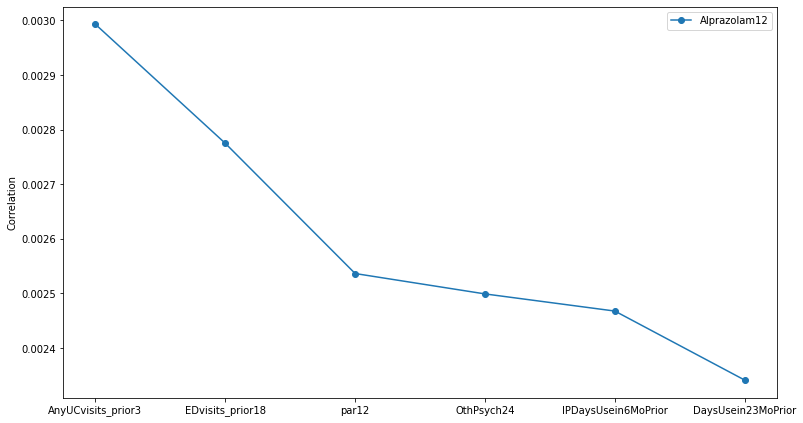

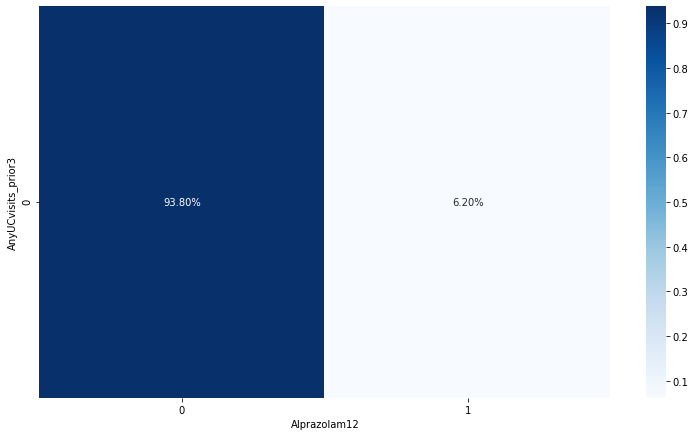

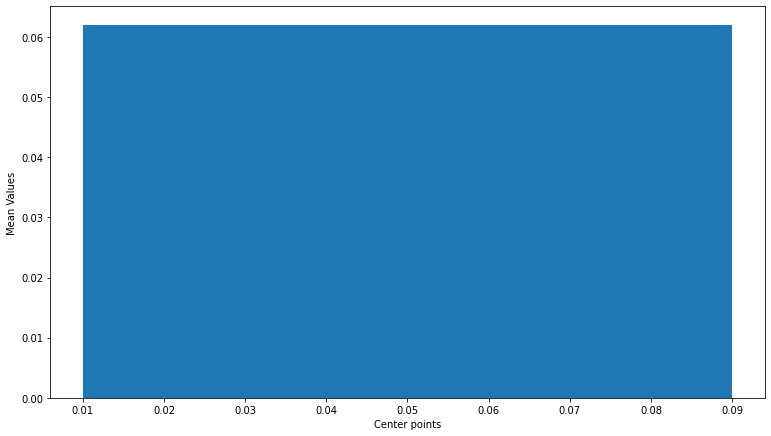

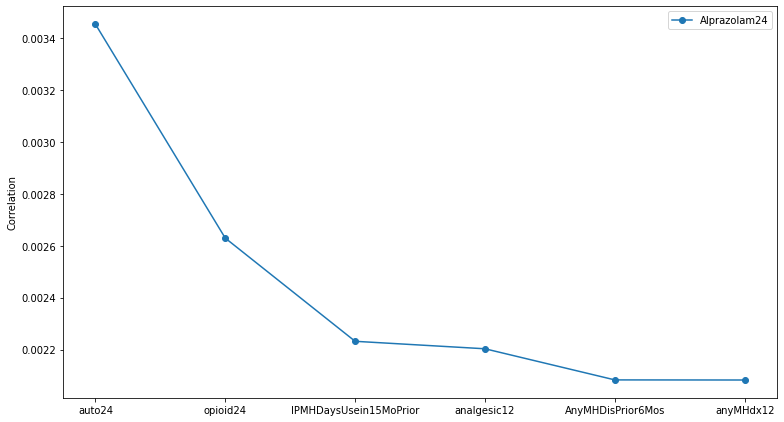

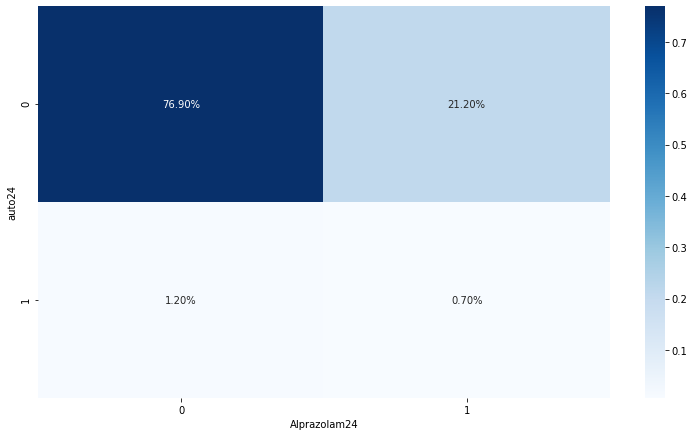

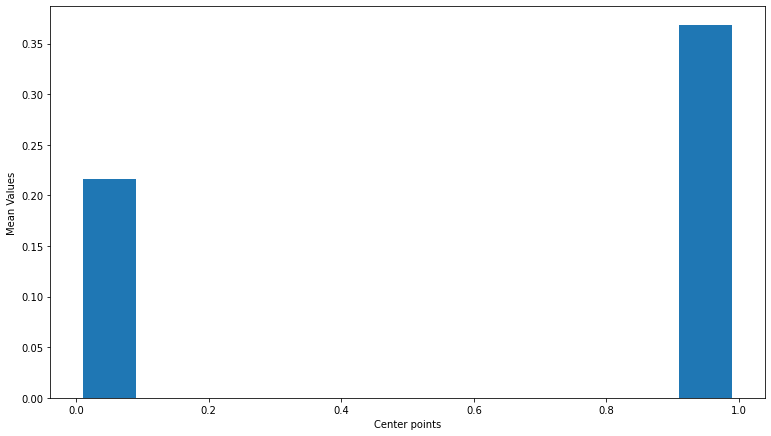

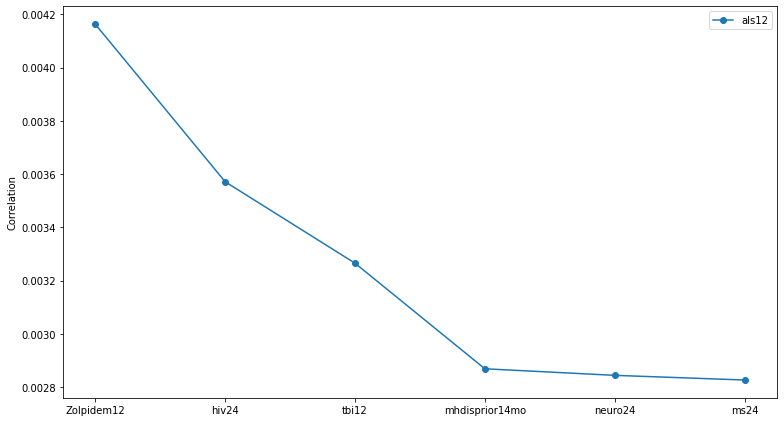

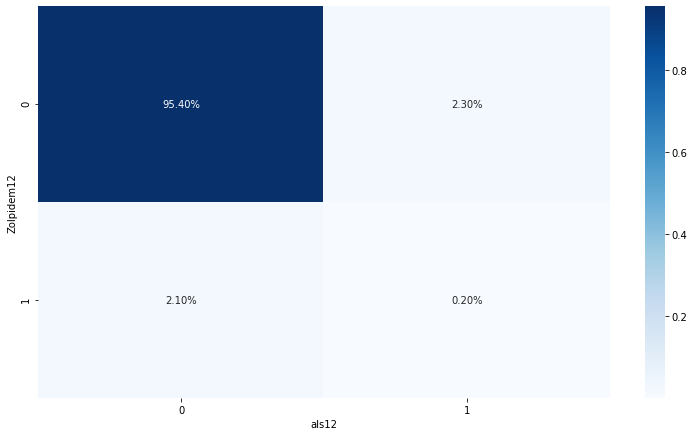

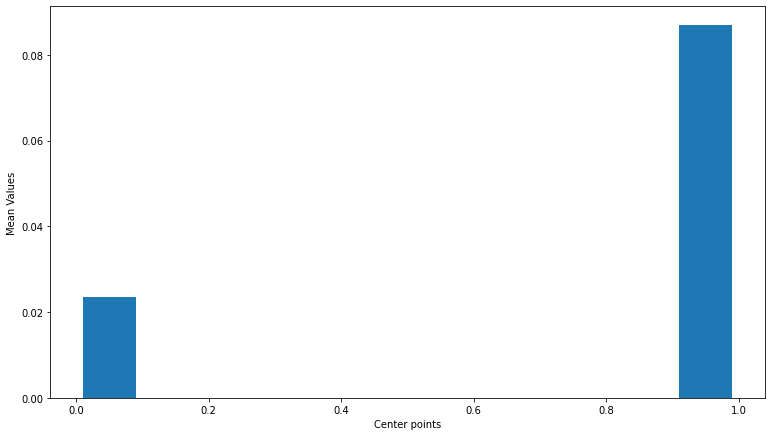

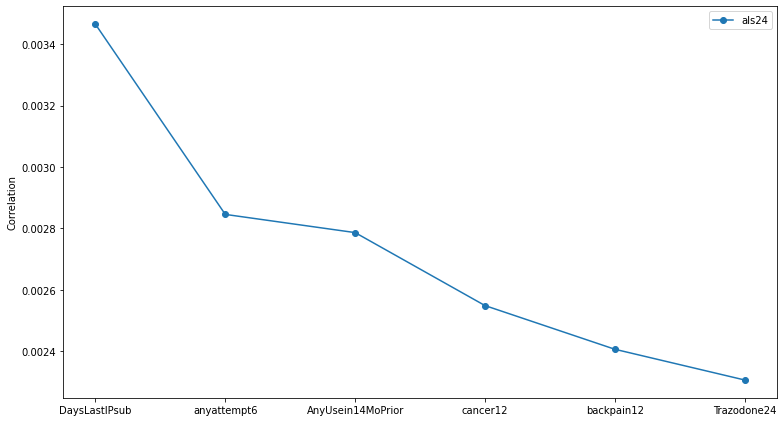

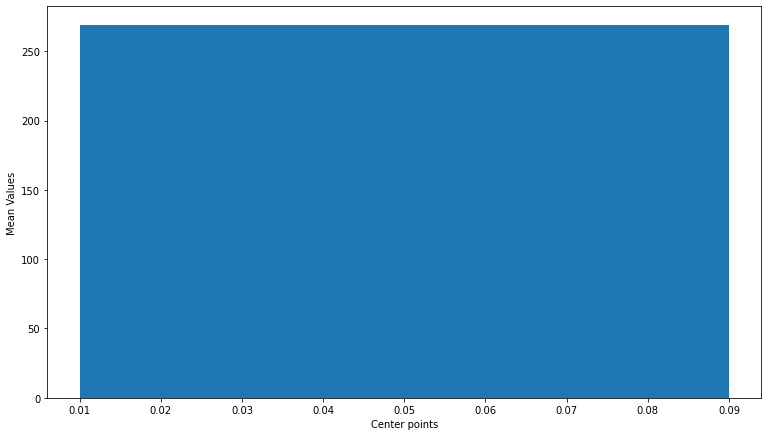

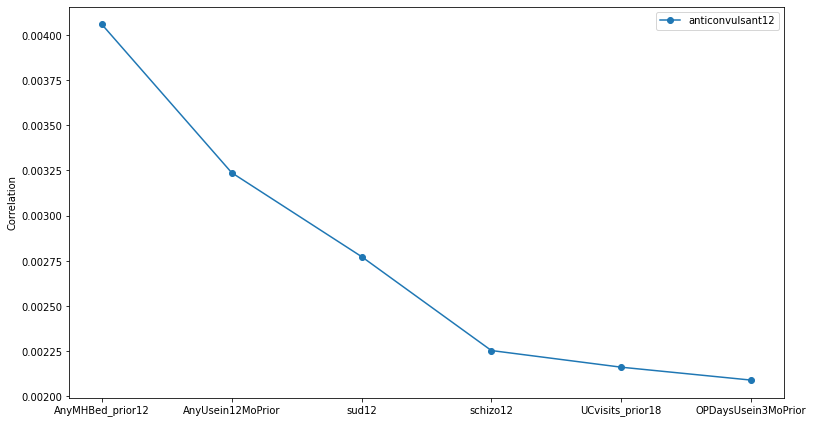

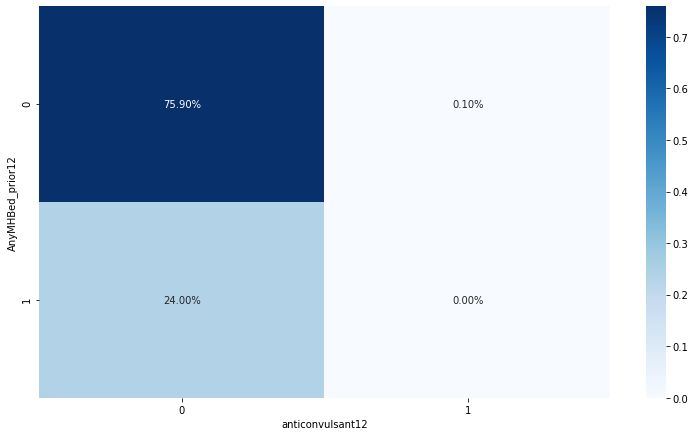

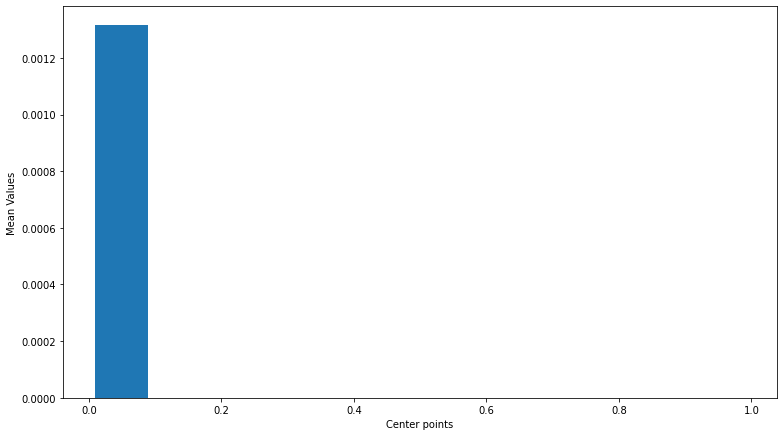

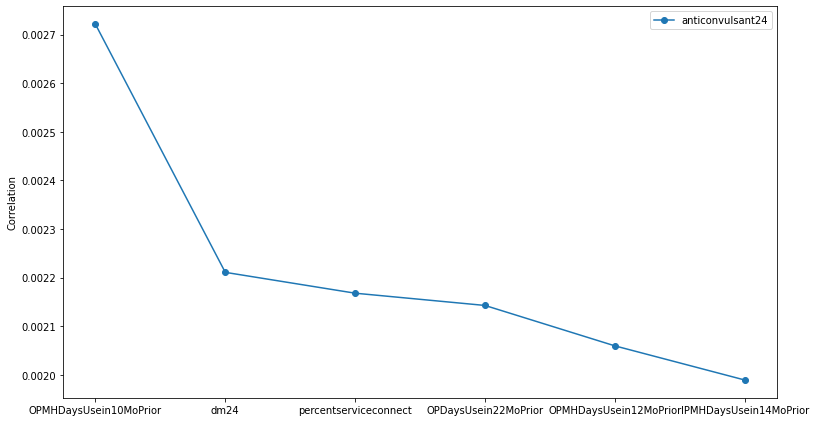

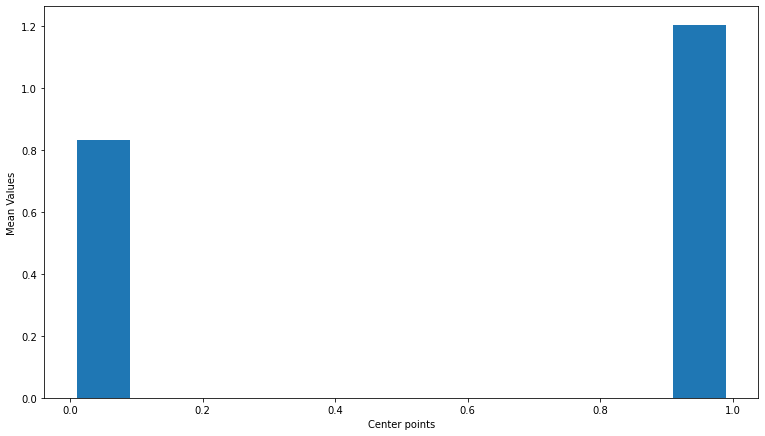

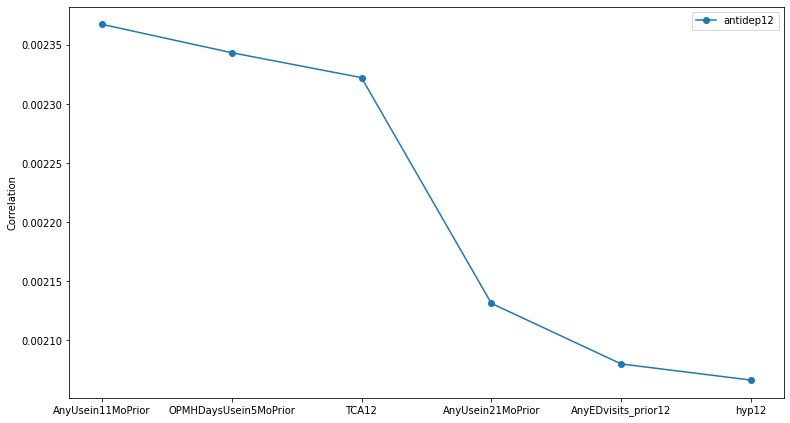

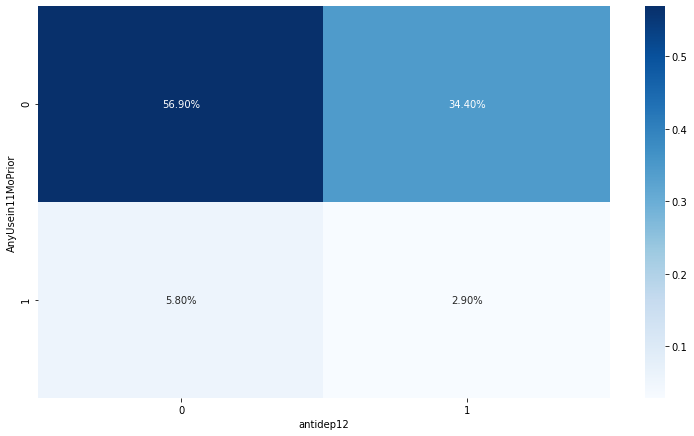

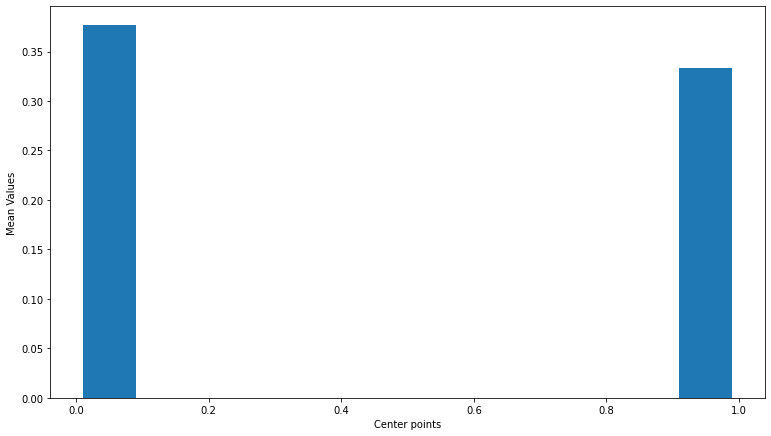

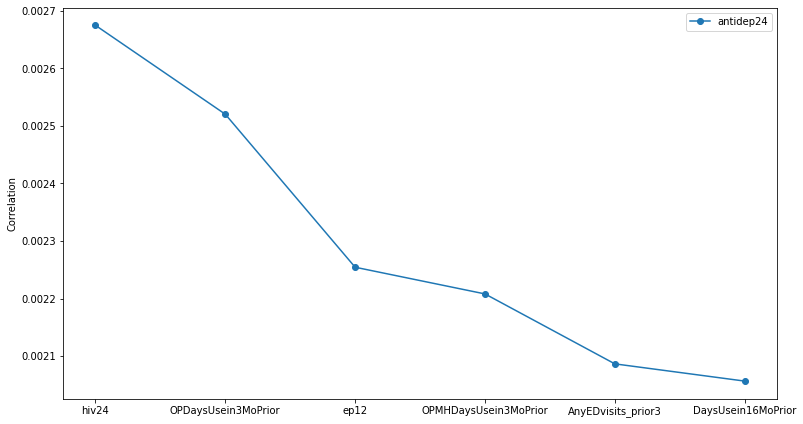

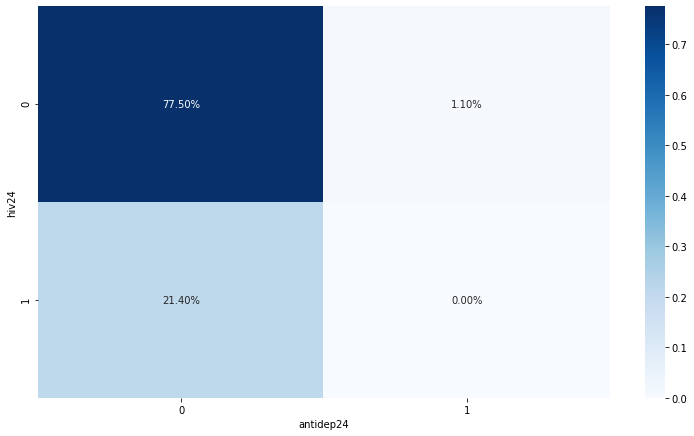

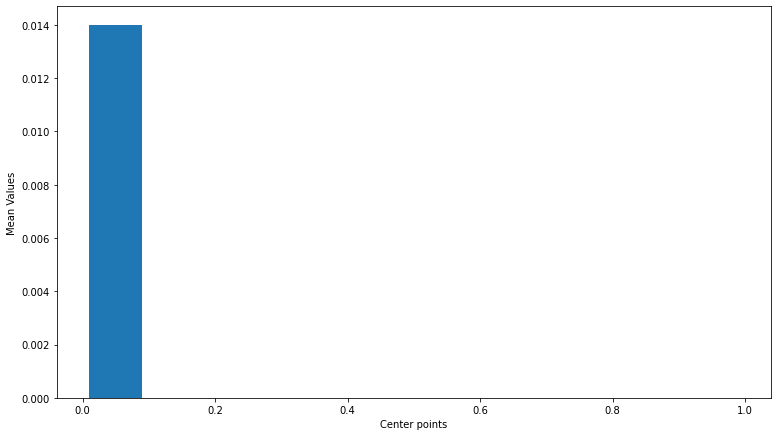

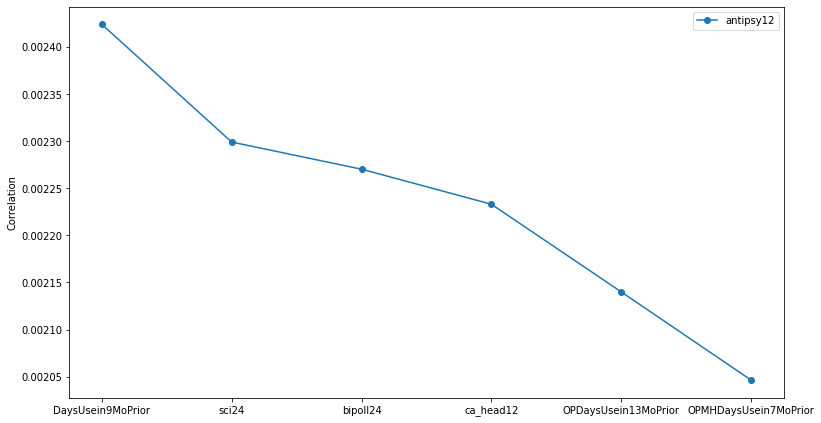

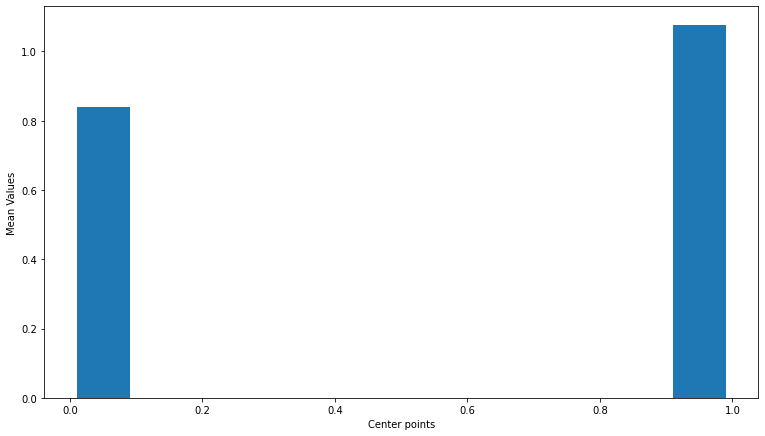

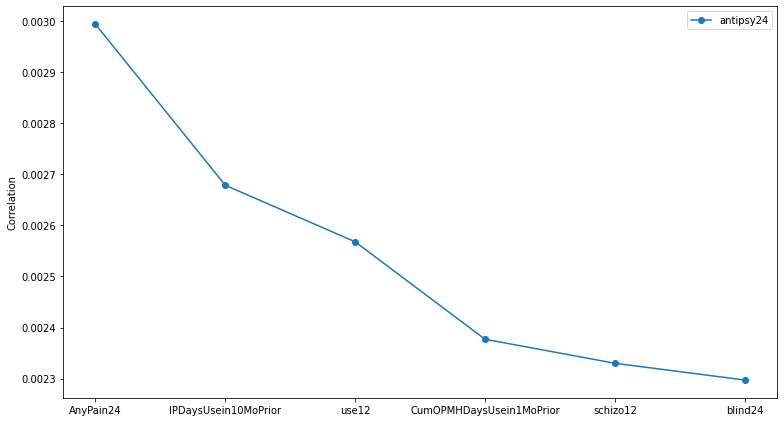

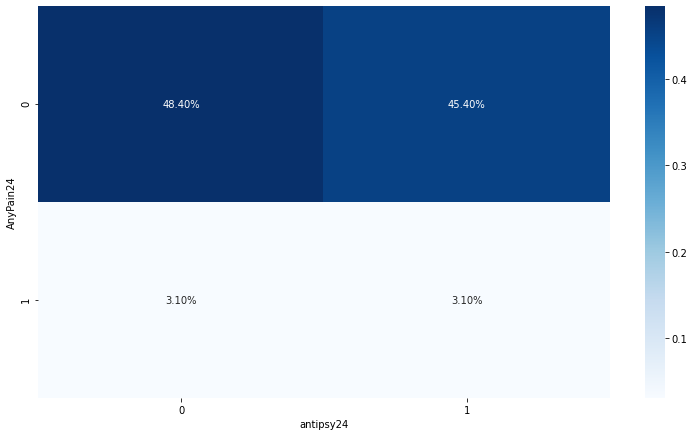

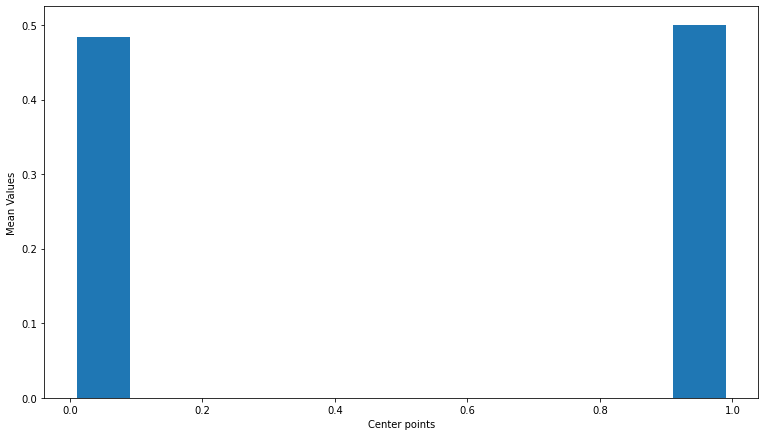

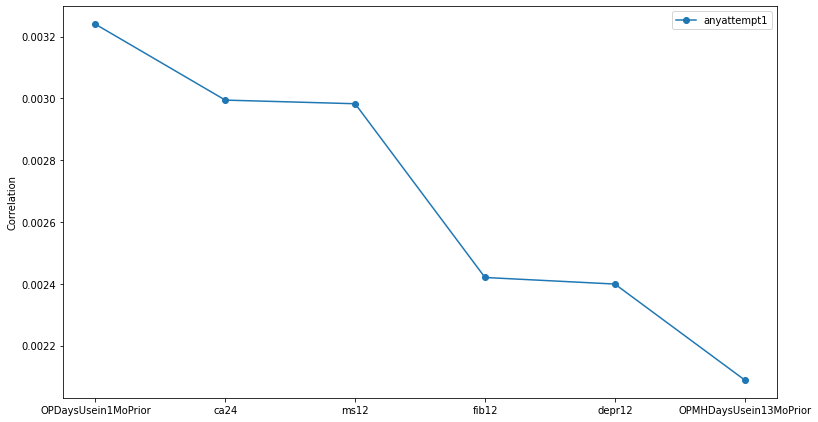

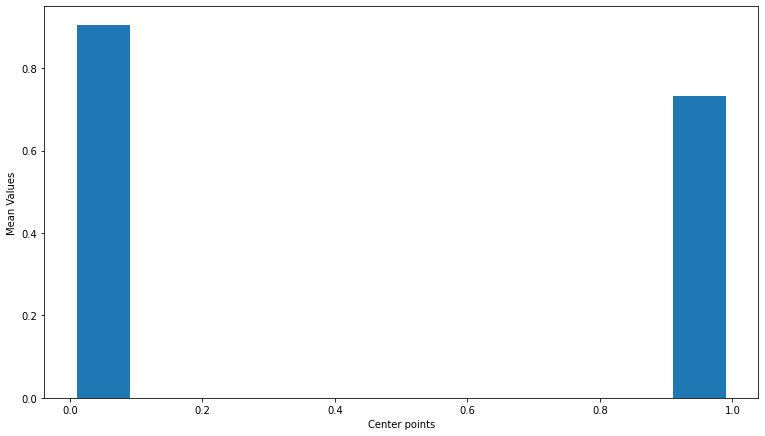

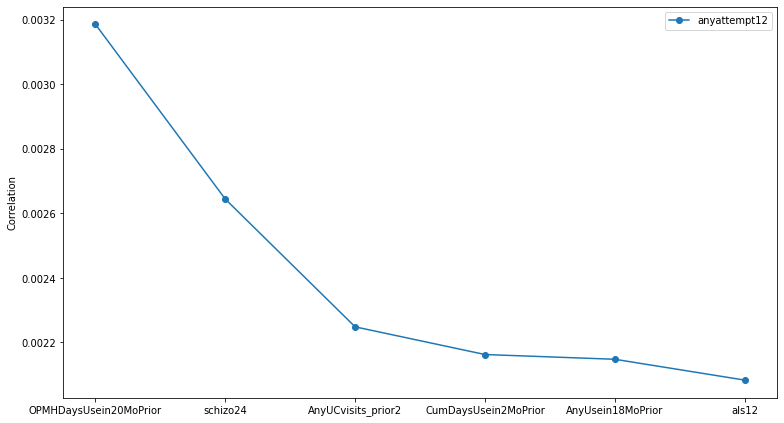

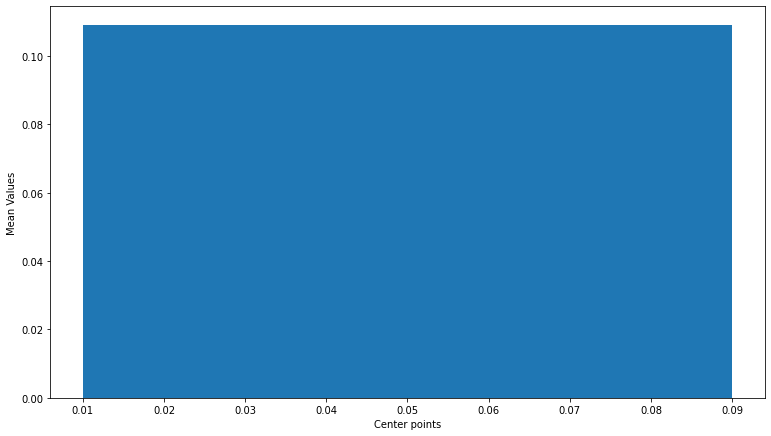

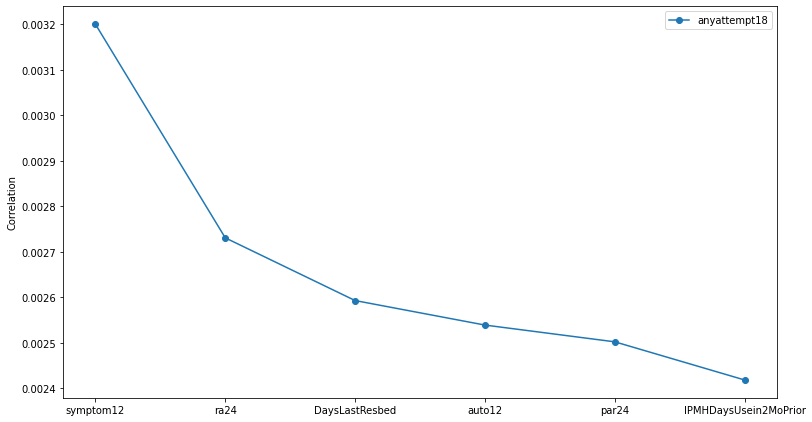

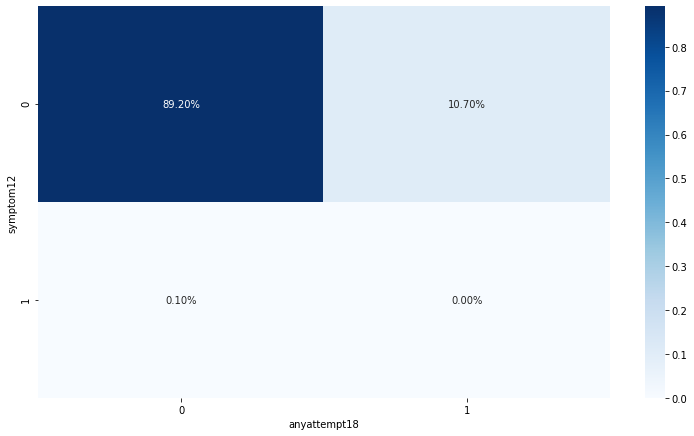

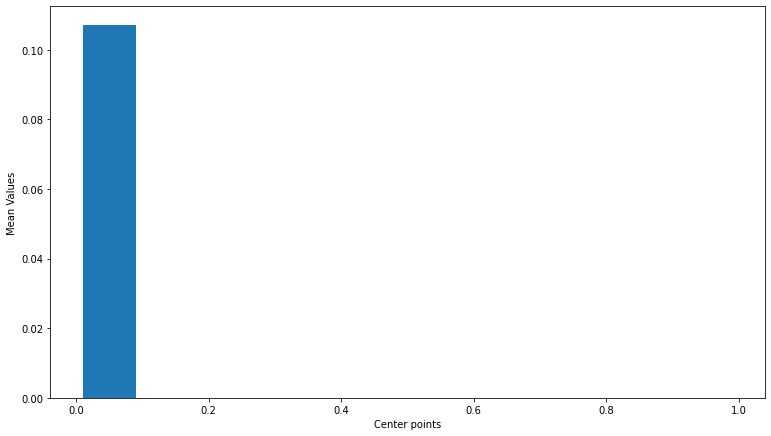

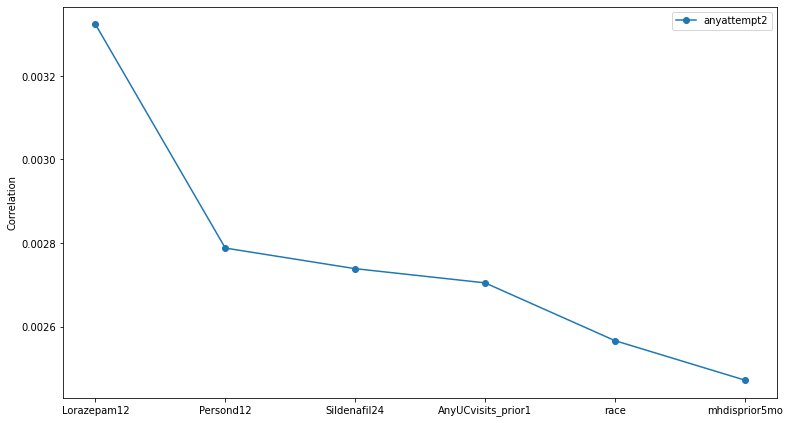

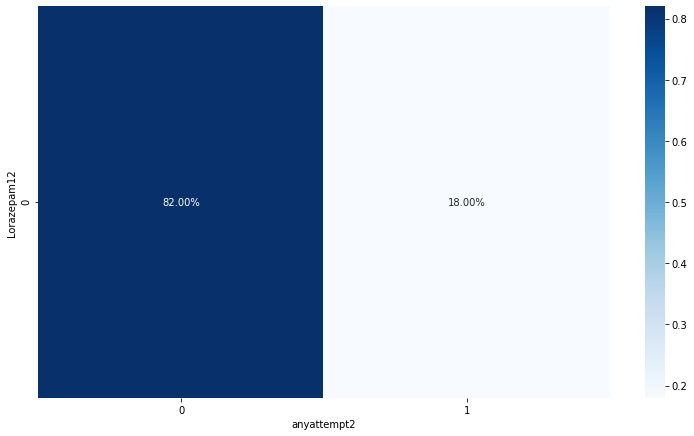

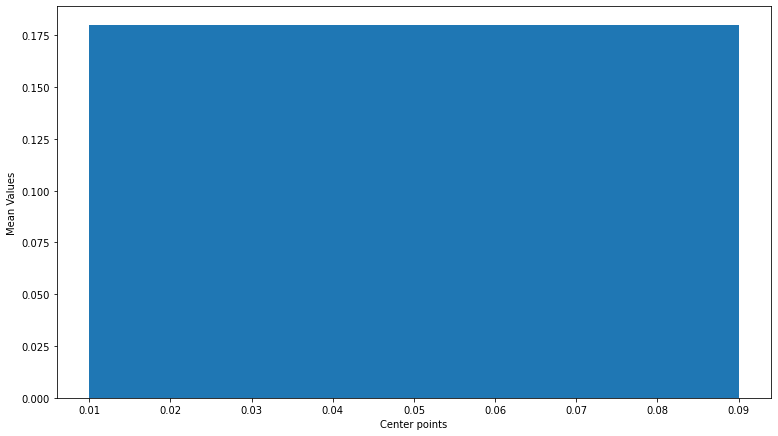

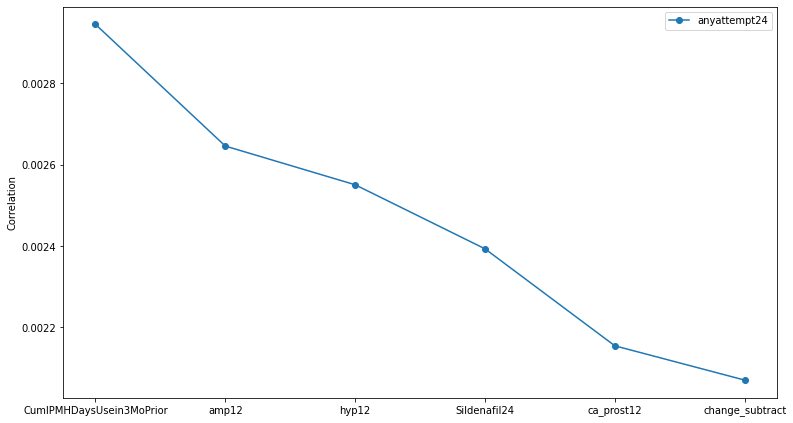

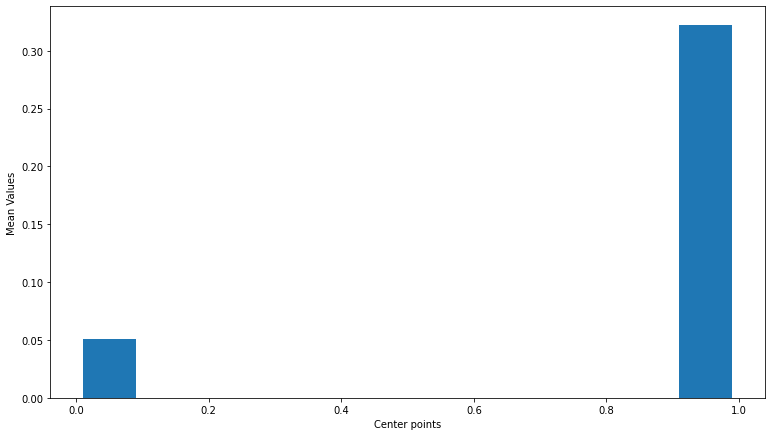

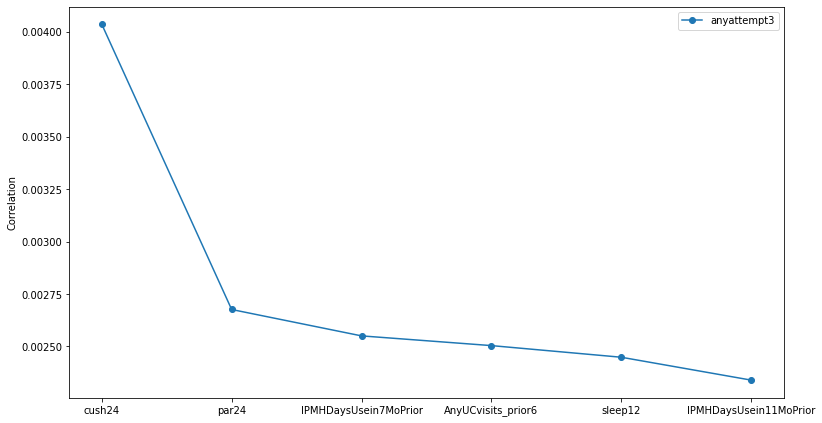

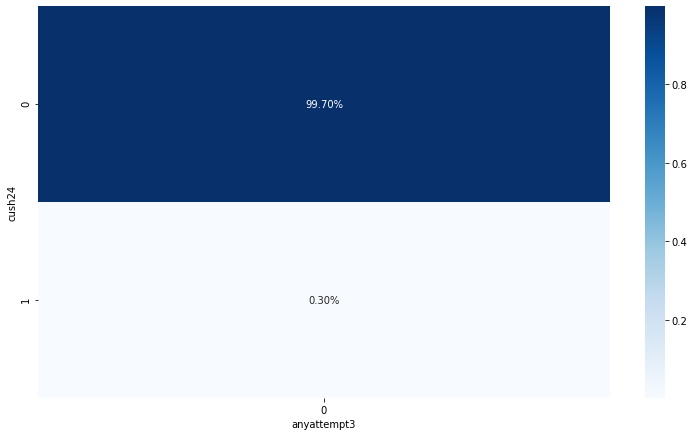

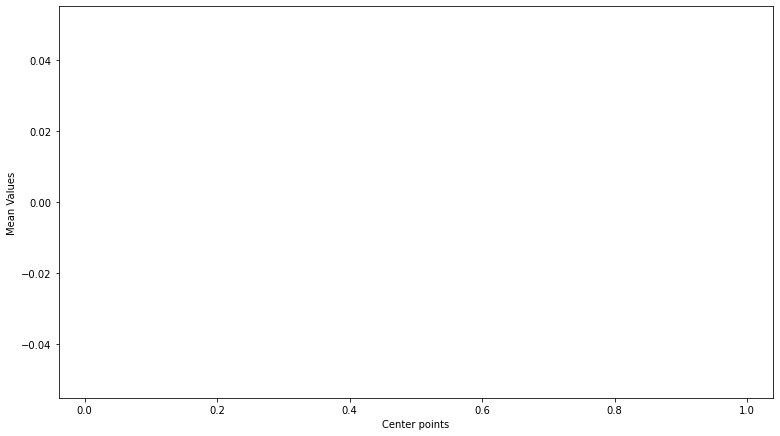

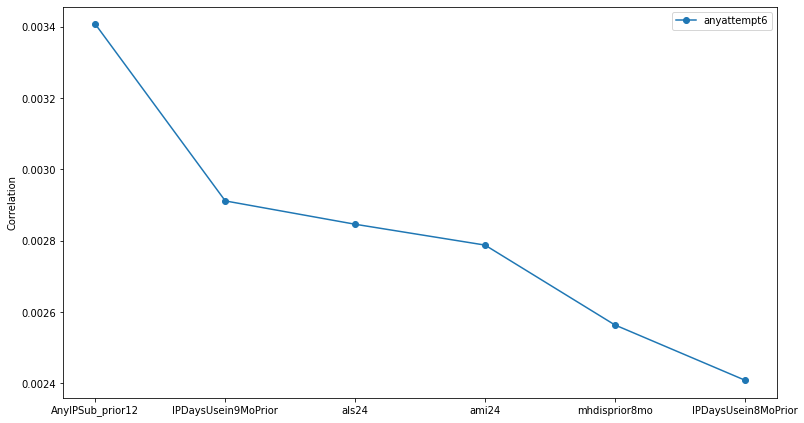

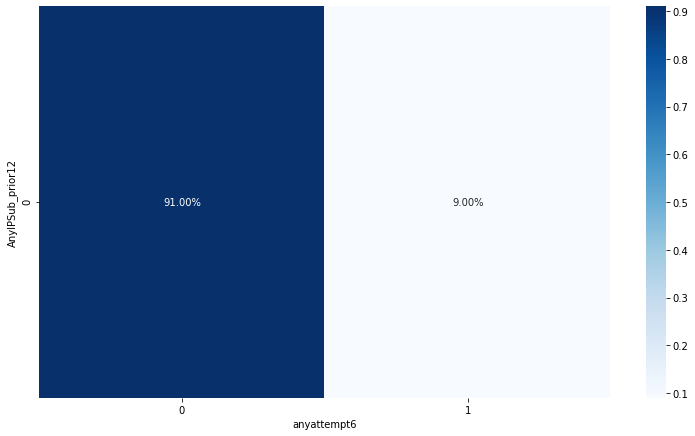

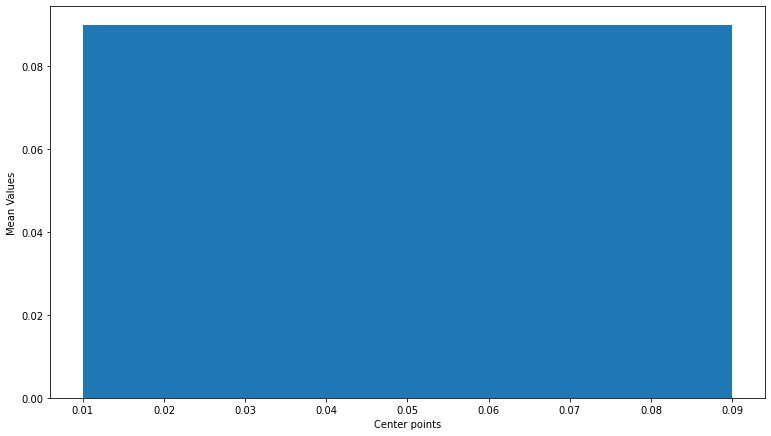

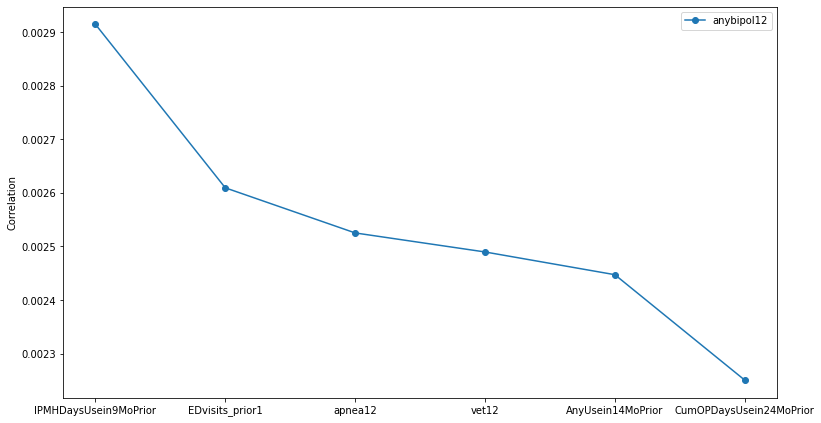

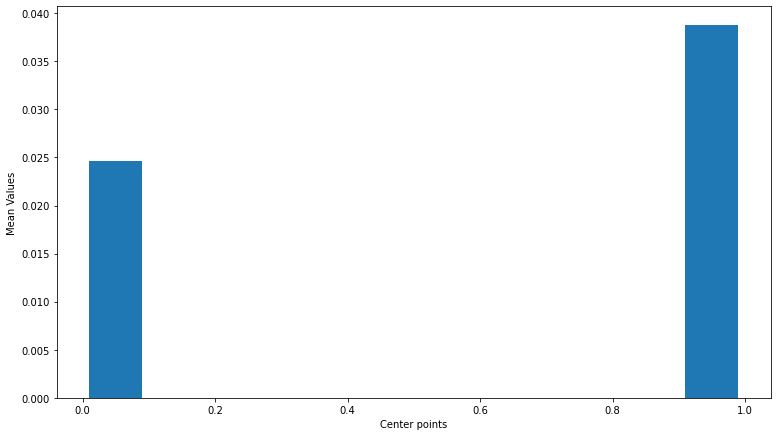

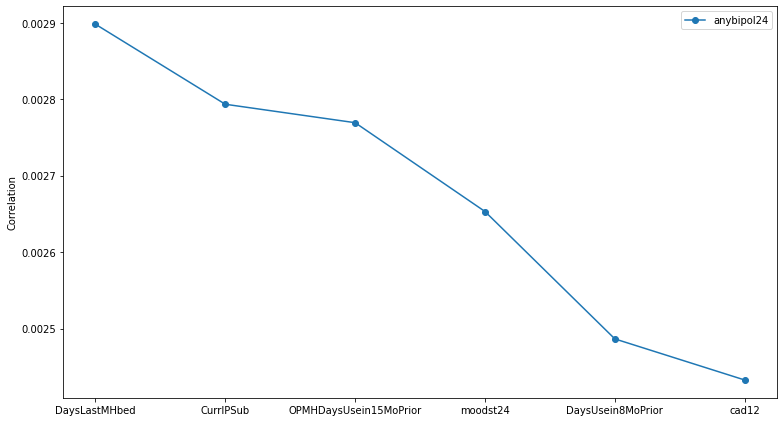

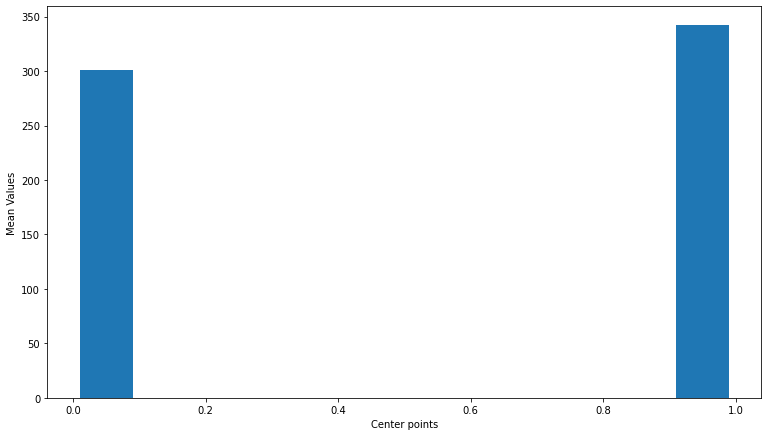

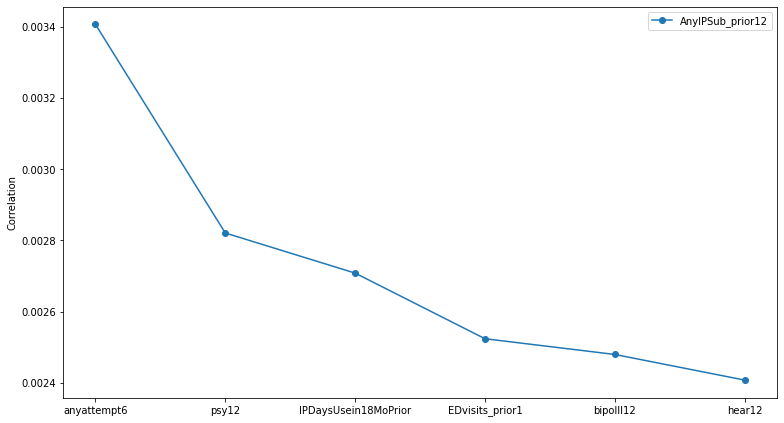

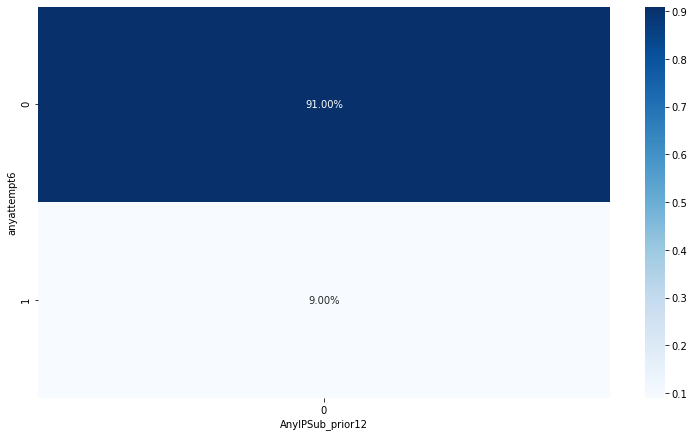

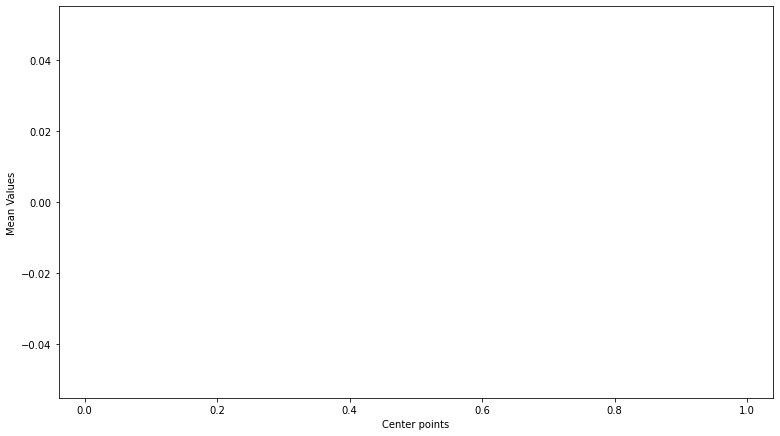

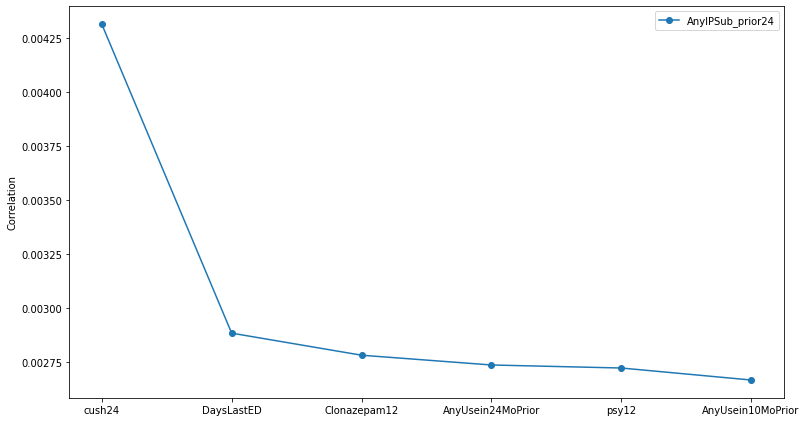

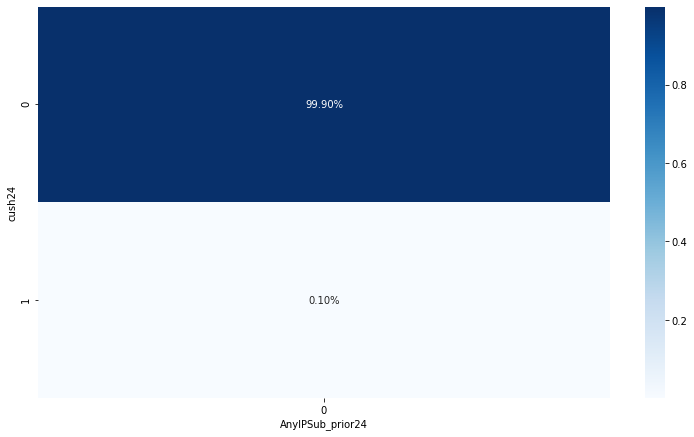

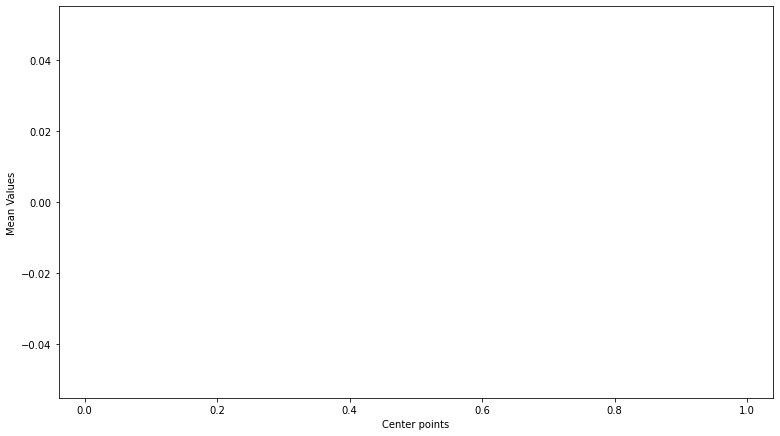

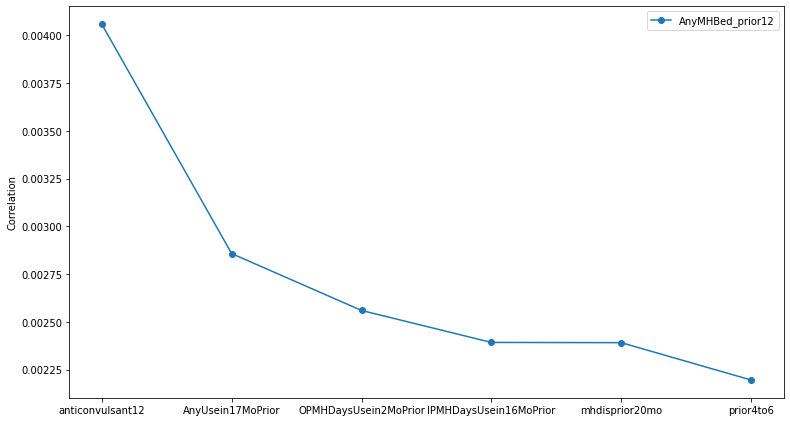

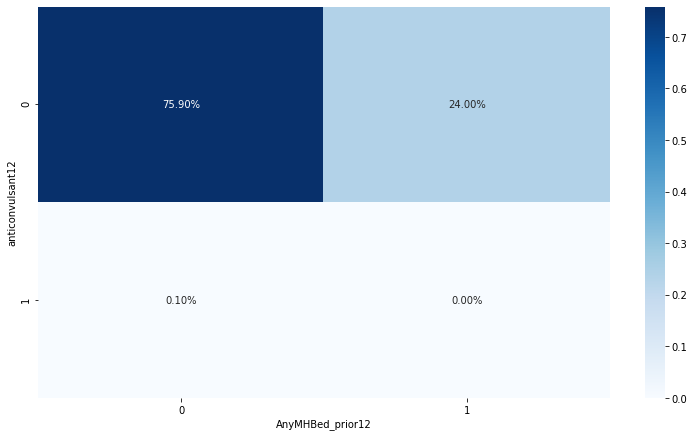

KeyboardInterrupt: 

In [6]:
output_response = apotheka.plots()

In [1]:
output_response['plots'][1]

NameError: name 'output_response' is not defined

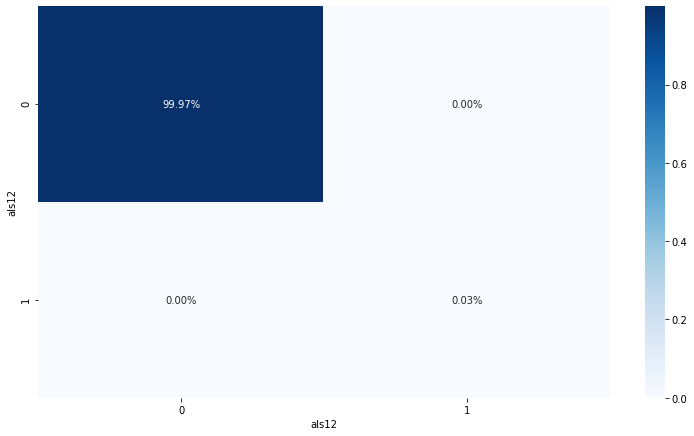

In [29]:
# im_b64 = apotheka.binned_stats('als12', 'Alprazolam12')
im_b64 = apotheka.confusion_mat_plot('als12','als12')
# with open("test.jpg", "rb") as f:
#     im_b64 = base64.b64encode(f.read())

im_bytes = base64.b64decode(im_b64)   # im_bytes is a binary image
im_file = BytesIO(im_bytes)  # convert image to file-like object
img = Image.open(im_file) 
img.show()

In [45]:
if 'feature_names' not in input_dict.keys():
    input_dict.update({'feature_names':['id', 'case', 'Alprazolam12', 'Alprazolam24', 'als12', 'als24', 'ami12', 'ami24', 'amp12', 'amp24', 'analgesic12', 'analgesic24', 'anticonvulsant12', 'anticonvulsant24', 'antidep12', 'antidep24', 'antipsy12', 'antipsy24', 'anyattempt1', 'anyattempt12', 'anyattempt18', 'anyattempt2', 'anyattempt24', 'anyattempt3', 'anyattempt6', 'anybipol12', 'anybipol24', 'AnyEDvisits_prior1', 'AnyEDvisits_prior12', 'AnyEDvisits_prior18', 'AnyEDvisits_prior2', 'AnyEDvisits_prior24', 'AnyEDvisits_prior3', 'AnyEDvisits_prior6', 'AnyIPSub_prior12', 'AnyIPSub_prior24', 'AnyMHBed_prior12', 'AnyMHBed_prior24', 'AnyMHDisPrior12Mos', 'AnyMHDisPrior1Mos', 'AnyMHDisPrior24Mos', 'AnyMHDisPrior3Mos', 'AnyMHDisPrior6Mos', 'anyMHdx12', 'anyMHdx24', 'anyMHtx12', 'anyMHtx24', 'AnyPain12', 'AnyPain24', 'AnyResBed_prior12', 'AnyResBed_prior24', 'AnyResSub_prior12', 'AnyResSub_prior24', 'AnyUCvisits_prior1', 'AnyUCvisits_prior12', 'AnyUCvisits_prior18', 'AnyUCvisits_prior2', 'AnyUCvisits_prior24', 'AnyUCvisits_prior3', 'AnyUCvisits_prior6', 'AnyUsein10MoPrior', 'AnyUsein11MoPrior', 'AnyUsein12MoPrior', 'AnyUsein13MoPrior', 'AnyUsein14MoPrior', 'AnyUsein15MoPrior', 'AnyUsein16MoPrior', 'AnyUsein17MoPrior', 'AnyUsein18MoPrior', 'AnyUsein19MoPrior', 'AnyUsein1MoPrior', 'AnyUsein20MoPrior', 'AnyUsein21MoPrior', 'AnyUsein22MoPrior', 'AnyUsein23MoPrior', 'AnyUsein24MoPrior', 'AnyUsein2MoPrior', 'AnyUsein3MoPrior', 'AnyUsein4MoPrior', 'AnyUsein5MoPrior', 'AnyUsein6MoPrior', 'AnyUsein7MoPrior', 'AnyUsein8MoPrior', 'AnyUsein9MoPrior', 'apnea12', 'apnea24', 'ARB12', 'ARB24', 'arth12', 'arth24', 'auto12', 'auto24', 'backpain12', 'backpain24', 'bipolI12', 'bipolI24', 'bipolII12', 'bipolII24', 'blind12', 'blind24', 'ca_head12', 'ca_head24', 'ca_prost12', 'ca_prost24', 'ca12', 'ca24', 'cad12', 'cad24', 'cancer12', 'cancer24', 'cess12', 'cess24', 'chronic12', 'chronic24', 'Clonazepam12', 'Clonazepam24', 'conc12', 'conc24', 'copd12', 'copd24', 'CurrIPSub', 'CurrMHBed', 'CurrResBed', 'CurrResSub', 'cush12', 'cush24', 'cva12', 'cva24', 'cvd12', 'cvd24', 'dementia12', 'dementia24', 'depr12', 'depr24', 'dm12', 'dm24', 'dt12', 'dt24', 'dysthymia12', 'dysthymia24', 'ep12', 'ep24', 'fib12', 'fib24', 'FirstUse1Yr', 'FirstUse2Yr', 'FirstUse3Yr', 'FirstUse4Yr', 'gu12', 'gu24', 'ha12', 'ha24', 'hc12', 'hc24', 'hear12', 'hear24', 'hemi12', 'hemi24', 'highrisk', 'hiv12', 'hiv24', 'homeless12', 'homeless24', 'hyp12', 'hyp24', 'lagca12', 'lagca24', 'Lorazepam12', 'Lorazepam24', 'mig12', 'mig24', 'Mirtazepam12', 'Mirtazepam24', 'moodst12', 'moodst24', 'ms12', 'ms24', 'neuro12', 'neuro24', 'opioid12', 'opioid24', 'OthAnxDis12', 'OthAnxDis24', 'OthPsych12', 'OthPsych24', 'par12', 'par24', 'Persond12', 'Persond24', 'psy12', 'psy24', 'ptsd12', 'ptsd24', 'ra12', 'ra24', 'rd12', 'rd24', 'relax12', 'relax24', 'schizo12', 'schizo24', 'sci12', 'sci24', 'sedative_anxiolytic12', 'sedative_anxiolytic24', 'Sildenafil12', 'Sildenafil24', 'sle12', 'sle24', 'sleep12', 'sleep24', 'Statin12', 'Statin24', 'sud12', 'sud24', 'symptom12', 'symptom24', 'tbi12', 'tbi24', 'TCA12', 'TCA24', 'tension12', 'tension24', 'thy12', 'thy24', 'tobacco12', 'tobacco24', 'topical12', 'topical24', 'Trazodone12', 'Trazodone24', 'use12', 'use24', 'vet12', 'vet24', 'vision12', 'vision24', 'Zolpidem12', 'Zolpidem24', 'age', 'Attempt1', 'Attempt12', 'Attempt18', 'Attempt2', 'Attempt24', 'Attempt3', 'Attempt6', 'change_divide', 'change_Sq', 'change_subtract', 'CumDaysUsein12MoPrior', 'CumDaysUsein18MoPrior', 'CumDaysUsein1MoPrior', 'CumDaysUsein24MoPrior', 'CumDaysUsein2MoPrior', 'CumDaysUsein3MoPrior', 'CumDaysUsein6MoPrior', 'CumIPDaysUsein12MoPrior', 'CumIPDaysUsein18MoPrior', 'CumIPDaysUsein1MoPrior', 'CumIPDaysUsein24MoPrior', 'CumIPDaysUsein2MoPrior', 'CumIPDaysUsein3MoPrior', 'CumIPDaysUsein6MoPrior', 'CumIPMHDaysUsein12MoPrior', 'CumIPMHDaysUsein18MoPrior', 'CumIPMHDaysUsein1MoPrior', 'CumIPMHDaysUsein24MoPrior', 'CumIPMHDaysUsein2MoPrior', 'CumIPMHDaysUsein3MoPrior', 'CumIPMHDaysUsein6MoPrior', 'CumOPDaysUsein12MoPrior', 'CumOPDaysUsein18MoPrior', 'CumOPDaysUsein1MoPrior', 'CumOPDaysUsein24MoPrior', 'CumOPDaysUsein2MoPrior', 'CumOPDaysUsein3MoPrior', 'CumOPDaysUsein6MoPrior', 'CumOPMHDaysUsein12MoPrior', 'CumOPMHDaysUsein18MoPrior', 'CumOPMHDaysUsein1MoPrior', 'CumOPMHDaysUsein24MoPrior', 'CumOPMHDaysUsein2MoPrior', 'CumOPMHDaysUsein3MoPrior', 'CumOPMHDaysUsein6MoPrior', 'DaysLastED', 'DaysLastIPsub', 'DaysLastMHbed', 'DaysLastResbed', 'DaysLastResSub', 'DaysUsein10MoPrior', 'DaysUsein11MoPrior', 'DaysUsein12MoPrior', 'DaysUsein13MoPrior', 'DaysUsein14MoPrior', 'DaysUsein15MoPrior', 'DaysUsein16MoPrior', 'DaysUsein17MoPrior', 'DaysUsein18MoPrior', 'DaysUsein19MoPrior', 'DaysUsein1MoPrior', 'DaysUsein20MoPrior', 'DaysUsein21MoPrior', 'DaysUsein22MoPrior', 'DaysUsein23MoPrior', 'DaysUsein24MoPrior', 'DaysUsein2MoPrior', 'DaysUsein3MoPrior', 'DaysUsein4MoPrior', 'DaysUsein5MoPrior', 'DaysUsein6MoPrior', 'DaysUsein7MoPrior', 'DaysUsein8MoPrior', 'DaysUsein9MoPrior', 'dob', 'EDvisits_prior1', 'EDvisits_prior12', 'EDvisits_prior18', 'EDvisits_prior2', 'EDvisits_prior24', 'EDvisits_prior3', 'EDvisits_prior6', 'FirstUse5yr', 'IPDaysUsein10MoPrior', 'IPDaysUsein11MoPrior', 'IPDaysUsein12MoPrior', 'IPDaysUsein13MoPrior', 'IPDaysUsein14MoPrior', 'IPDaysUsein15MoPrior', 'IPDaysUsein16MoPrior', 'IPDaysUsein17MoPrior', 'IPDaysUsein18MoPrior', 'IPDaysUsein19MoPrior', 'IPDaysUsein1MoPrior', 'IPDaysUsein20MoPrior', 'IPDaysUsein21MoPrior', 'IPDaysUsein22MoPrior', 'IPDaysUsein23MoPrior', 'IPDaysUsein24MoPrior', 'IPDaysUsein2MoPrior', 'IPDaysUsein3MoPrior', 'IPDaysUsein4MoPrior', 'IPDaysUsein5MoPrior', 'IPDaysUsein6MoPrior', 'IPDaysUsein7MoPrior', 'IPDaysUsein8MoPrior', 'IPDaysUsein9MoPrior', 'IPMHDaysUsein10MoPrior', 'IPMHDaysUsein11MoPrior', 'IPMHDaysUsein12MoPrior', 'IPMHDaysUsein13MoPrior', 'IPMHDaysUsein14MoPrior', 'IPMHDaysUsein15MoPrior', 'IPMHDaysUsein16MoPrior', 'IPMHDaysUsein17MoPrior', 'IPMHDaysUsein18MoPrior', 'IPMHDaysUsein19MoPrior', 'IPMHDaysUsein1MoPrior', 'IPMHDaysUsein20MoPrior', 'IPMHDaysUsein21MoPrior', 'IPMHDaysUsein22MoPrior', 'IPMHDaysUsein23MoPrior', 'IPMHDaysUsein24MoPrior', 'IPMHDaysUsein2MoPrior', 'IPMHDaysUsein3MoPrior', 'IPMHDaysUsein4MoPrior', 'IPMHDaysUsein5MoPrior', 'IPMHDaysUsein6MoPrior', 'IPMHDaysUsein7MoPrior', 'IPMHDaysUsein8MoPrior', 'IPMHDaysUsein9MoPrior', 'IPsub_prior12', 'IPsub_prior24', 'LastEDVisit', 'MHbed_prior12', 'MHbed_prior24', 'mhdisprior10mo', 'mhdisprior11mo', 'mhdisprior12mo', 'mhdisprior13mo', 'mhdisprior14mo', 'mhdisprior15mo', 'mhdisprior16mo', 'mhdisprior17mo', 'mhdisprior18mo', 'mhdisprior19mo', 'mhdisprior1mo', 'mhdisprior20mo', 'mhdisprior21mo', 'mhdisprior22mo', 'mhdisprior23mo', 'mhdisprior24mo', 'mhdisprior2mo', 'mhdisprior3mo', 'mhdisprior4mo', 'mhdisprior5mo', 'mhdisprior6mo', 'mhdisprior7mo', 'mhdisprior8mo', 'mhdisprior9mo', 'month', 'Month_Ind', 'OPDaysUsein10MoPrior', 'OPDaysUsein11MoPrior', 'OPDaysUsein12MoPrior', 'OPDaysUsein13MoPrior', 'OPDaysUsein14MoPrior', 'OPDaysUsein15MoPrior', 'OPDaysUsein16MoPrior', 'OPDaysUsein17MoPrior', 'OPDaysUsein18MoPrior', 'OPDaysUsein19MoPrior', 'OPDaysUsein1MoPrior', 'OPDaysUsein20MoPrior', 'OPDaysUsein21MoPrior', 'OPDaysUsein22MoPrior', 'OPDaysUsein23MoPrior', 'OPDaysUsein24MoPrior', 'OPDaysUsein2MoPrior', 'OPDaysUsein3MoPrior', 'OPDaysUsein4MoPrior', 'OPDaysUsein5MoPrior', 'OPDaysUsein6MoPrior', 'OPDaysUsein7MoPrior', 'OPDaysUsein8MoPrior', 'OPDaysUsein9MoPrior', 'OPMHDaysUsein10MoPrior', 'OPMHDaysUsein11MoPrior', 'OPMHDaysUsein12MoPrior', 'OPMHDaysUsein13MoPrior', 'OPMHDaysUsein14MoPrior', 'OPMHDaysUsein15MoPrior', 'OPMHDaysUsein16MoPrior', 'OPMHDaysUsein17MoPrior', 'OPMHDaysUsein18MoPrior', 'OPMHDaysUsein19MoPrior', 'OPMHDaysUsein1MoPrior', 'OPMHDaysUsein20MoPrior', 'OPMHDaysUsein21MoPrior', 'OPMHDaysUsein22MoPrior', 'OPMHDaysUsein23MoPrior', 'OPMHDaysUsein24MoPrior', 'OPMHDaysUsein2MoPrior', 'OPMHDaysUsein3MoPrior', 'OPMHDaysUsein4MoPrior', 'OPMHDaysUsein5MoPrior', 'OPMHDaysUsein6MoPrior', 'OPMHDaysUsein7MoPrior', 'OPMHDaysUsein8MoPrior', 'OPMHDaysUsein9MoPrior', 'percentserviceconnect', 'prior0to3', 'prior4to6', 'race', 'race2', 'region', 'Resbed_prior12', 'Resbed_prior24', 'ResSub_prior12', 'ResSub_prior24', 'serviceconnectedgroup', 'UCvisits_prior1', 'UCvisits_prior12', 'UCvisits_prior18', 'UCvisits_prior2', 'UCvisits_prior24', 'UCvisits_prior3', 'UCvisits_prior6', 'weight_pm', 'white', 'YearsSinceFirstUse']})

    


In [66]:
img = Image.open("../plots/correlation_"+ 'als12.png')
img = img.resize([100,100])
im_file = io.BytesIO()
img.save(im_file, format="png")
im_bytes = im_file.getvalue()  # im_bytes: image in binary format.
im_b64 = base64.b64encode(im_bytes)


b'iVBORw0KGgoAAAANSUhEUgAAAGQAAABkCAYAAABw4pVUAAAJ2UlEQVR4nO2dyW8b1x3HP7NzSHERRVqLJe+OFyVx4hpogSAJiqInAwmaoj330nNPvdQ9FT30XyjQP6FAenDgBi1Qp+mK2m6S1k6dxZa8yJJMmaIoistsPTxKVhSRMyRFSiTnAxDUcGbePM13fm/5vfd+AyEhISEhISEhISEhISEhISEhDZBaPSGdTidM00x0IzODzOPHj5cAy+84P0FGgHHABGpA4erVqz86efLkzzvP4vBQLpfta9euvXblypU7fseqPvtjwBFgFNCBP8fj8ezZs2dH9iCfA4VtO+C5ePVtWZa39pVKJXdmZkbe/cyv4idIDdgAnPp2JJFIrG/uLJQtXM9jNKoHz/kA4nkeigySrG3+Qi63wvr6OrZtMzY25gZNy0+QPPDPRjuv/WeRYtXix6+fCHq9gWVuZYNff3ifF8YTfO/FNL97913Oz86SzWbxPM8/gTqBzKgR56cSaIqM4wa/4KCSjulMJk1mRqNoiszk1BS1Wo1CoYCiKNRqtUDp+FlIU16eTpKIqDzKb3B0LNZJUn3PiKHwk++c3tq+fPny1t+rq6uB0+lIEIDp0Sg35p9xJB1DarkRPRhIkkS1WsPzqrvud10XXQ9Wz3YsiKpIpKI6TwplplJmp8n1LdFotOn+oEVWR3XIJsczUR7ly3uR1NCzJ4IYqoKpK+TWdzfZkOD4CaIDaeBQ/XtEUZRd29QnMjHmcqU9zt7w4VeHpIBz9W8T+LhUKhm7HRgzVBRZplC2SJraboeEBMDPQrz6MTb13rrrug3bUsczMe6HVtIRfhayAvwDIUwNUGKxWMOKIhXVsJc9SlWbmNFxA24o8bMQFygDlfrflud5TXsbR8eioZV0wJ60sraTjRuUqg5VO7A/LWQbey4IwEzaDFtcbdIVQSaTEfIbNezQ6dgyXRFEkiQmkhEermx0I/mBpiuCAMyMRl

In [44]:
binary_features=[]
cont_features =[]
for name in apotheka.df.columns:
    length = (len(apotheka.df[name].unique()))# + '\t' + name)
    if name == 'id'
        continue
    if length > 2:
        cont_features.append(name)
    else:
        binary_features.append(name)
        
        
print(cont_features)

['id', 'case', 'Alprazolam12', 'Alprazolam24', 'als12', 'als24', 'ami12', 'ami24', 'amp12', 'amp24', 'analgesic12', 'analgesic24', 'anticonvulsant12', 'anticonvulsant24', 'antidep12', 'antidep24', 'antipsy12', 'antipsy24', 'anyattempt1', 'anyattempt12', 'anyattempt18', 'anyattempt2', 'anyattempt24', 'anyattempt3', 'anyattempt6', 'anybipol12', 'anybipol24', 'AnyEDvisits_prior1', 'AnyEDvisits_prior12', 'AnyEDvisits_prior18', 'AnyEDvisits_prior2', 'AnyEDvisits_prior24', 'AnyEDvisits_prior3', 'AnyEDvisits_prior6', 'AnyIPSub_prior12', 'AnyIPSub_prior24', 'AnyMHBed_prior12', 'AnyMHBed_prior24', 'AnyMHDisPrior12Mos', 'AnyMHDisPrior1Mos', 'AnyMHDisPrior24Mos', 'AnyMHDisPrior3Mos', 'AnyMHDisPrior6Mos', 'anyMHdx12', 'anyMHdx24', 'anyMHtx12', 'anyMHtx24', 'AnyPain12', 'AnyPain24', 'AnyResBed_prior12', 'AnyResBed_prior24', 'AnyResSub_prior12', 'AnyResSub_prior24', 'AnyUCvisits_prior1', 'AnyUCvisits_prior12', 'AnyUCvisits_prior18', 'AnyUCvisits_prior2', 'AnyUCvisits_prior24', 'AnyUCvisits_prior3', 

<AxesSubplot:>

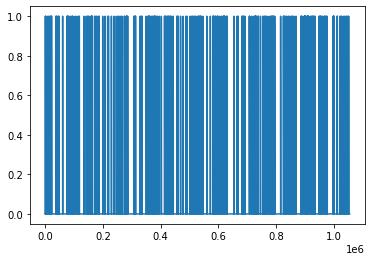

In [31]:
apotheka.df['anyattempt1'].

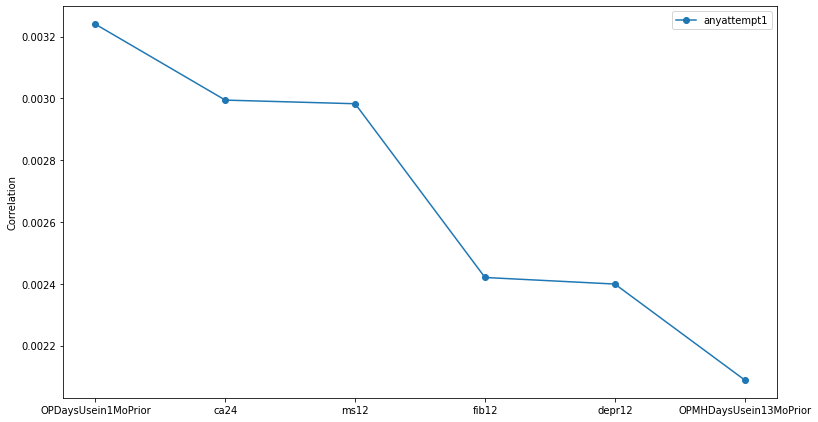

In [34]:
im = apotheka.plot_correlations('anyattempt1')

In [7]:
sample = apotheka.df.sample(1000)
sample.to_csv('../../data/sample_data.csv')